# Full Training Pipeline: Synthetic Data → Training → Inference

This notebook demonstrates the complete PtychoPINN workflow:

1. **Load a reference dataset** — extract the probe function and material distribution
2. **Fit distribution models** — histogram, statistics, and GMM from the reference object
3. **Select an object generation method** — choose from 13 available methods
4. **Generate and visualize synthetic objects** — inspect before committing
5. **Generate the full synthetic dataset** — write NPZ files for training
6. **Train a model** — Lightning-only training with configurable parameters
7. **Run inference** — reconstruct from a separate test dataset
8. **Visualize results** — amplitude/phase comparisons and Re-Im distributions

### Prerequisites
- GPU required (training uses `accelerator='gpu'`)
- PtychoPINN installed with `pip install -e .[torch]`
- A reference NPZ file containing `objectGuess` and `probeGuess` keys

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from pathlib import Path
from scipy.ndimage import gaussian_filter
from IPython.display import SVG, display
import glob

# Data generation
from ptycho_torch.datagen.objects import (
    fit_gmm_from_objects,
    compute_reim_statistics,
    create_density_histogram_reim,
)
from ptycho_torch.datagen.datagen import (
    simulate_synthetic_objects,
    simulate_multiple_experiments,
)

# Configuration
from ptycho_torch.config_params import (
    DataConfig, ModelConfig, TrainingConfig, InferenceConfig, DatagenConfig,
    update_existing_config,
)

# Training
from ptycho_torch.train import main_lightning

# Inference and visualization
from ptycho_torch.inference import (
    load_and_predict_lightning,
    plot_amp_and_phase,
    plot_reim_histogram,
)

# Utilities
from ptycho_torch.utils import remove_all_files

%matplotlib inline

In [2]:
# ============================================================
# USER CONFIGURATION — edit these paths and parameters
# ============================================================

# Reference NPZ file (must contain objectGuess and probeGuess)
NPZ_BASE_PATH = '../../data/pinn_velo_ic_2'
NPZ_PATH = glob.glob(NPZ_BASE_PATH + '/*.npz')[0]

# Patch size N (must match probe spatial dimensions)
N = 64

# Synthetic object canvas size (scales with N)
canvas_scale = N / 64
IMAGE_SIZE = (int(250 * canvas_scale), int(250 * canvas_scale))

# Dataset generation parameters
N_OBJECTS = 4            # Number of unique synthetic objects
DIFF_PER_OBJECT = 7000   # Diffraction patterns per object

# Output directories (relative to project root via ../../data)
SYNTHETIC_DATA_DIR = '../../data/synthetic_pipeline_demo'
TRAINING_OUTPUT_DIR = '../../data/training_pipeline_demo'

# Inference test data — must be a separate NPZ file (not the training data)
INFERENCE_NPZ_PATH = '../../data/pinn_velo_ic_2'
INFERENCE_OUTPUT_DIR = '../../data/inference_pipeline_demo'

print(f'Reference NPZ: {NPZ_PATH}')
print(f'Patch size N: {N}')
print(f'Canvas size: {IMAGE_SIZE}')
print(f'Dataset: {N_OBJECTS} objects x {DIFF_PER_OBJECT} patterns each')

Reference NPZ: ../../data/pinn_velo_ic_2/nxs_data_ic_2_64_train.npz
Patch size N: 64
Canvas size: (250, 250)
Dataset: 4 objects x 7000 patterns each


---
## 1. Load Reference Dataset

Load a reference NPZ file containing:
- `objectGuess` — complex-valued 2D array of the reconstructed object
- `probeGuess` — complex-valued 2D or 3D array (single-mode or multi-mode probe)

The object provides the material Re-Im distribution we want to replicate in synthetic data. The probe is reused directly for diffraction simulation.

In [3]:
npz_data = np.load(NPZ_PATH)
ref_obj = npz_data['objectGuess']
probe = npz_data['probeGuess']

print(f'objectGuess: shape={ref_obj.shape}, dtype={ref_obj.dtype}')
print(f'  Amplitude range: [{np.abs(ref_obj).min():.4f}, {np.abs(ref_obj).max():.4f}]')
print(f'  Re range: [{ref_obj.real.min():.4f}, {ref_obj.real.max():.4f}]')
print(f'  Im range: [{ref_obj.imag.min():.4f}, {ref_obj.imag.max():.4f}]')
print()
print(f'probeGuess: shape={probe.shape}, dtype={probe.dtype}')
if probe.ndim == 3:
    print(f'  Multi-mode probe with {probe.shape[0]} modes')
    print(f'  Spatial dimensions: {probe.shape[1]}x{probe.shape[2]}')
elif probe.ndim == 2:
    print(f'  Single-mode probe: {probe.shape[0]}x{probe.shape[1]}')

objectGuess: shape=(465, 468), dtype=complex64
  Amplitude range: [0.0000, 1.6401]
  Re range: [-0.1964, 1.3113]
  Im range: [-0.2896, 1.3992]

probeGuess: shape=(64, 64), dtype=complex64
  Single-mode probe: 64x64


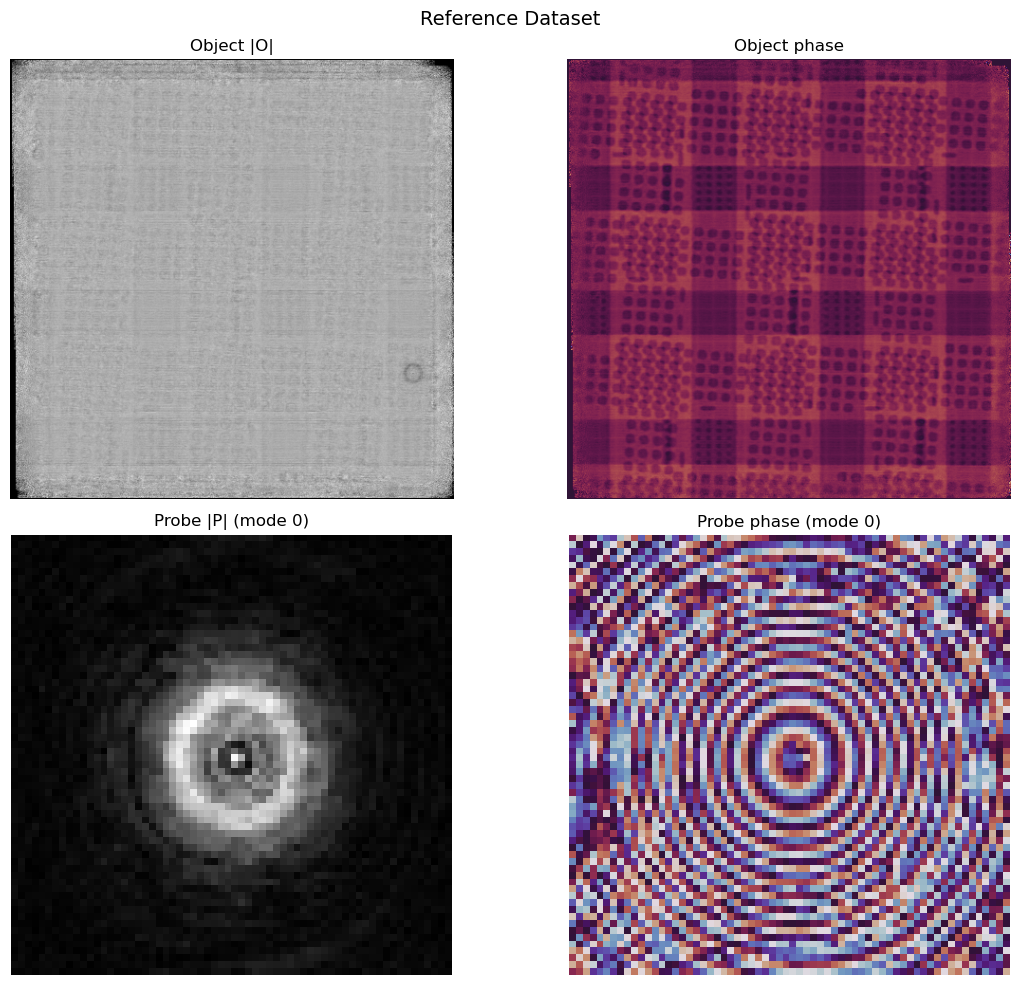

In [4]:
# Visualize reference object and probe
probe_display = probe[0] if probe.ndim == 3 else probe

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(np.abs(ref_obj), cmap='gray')
axes[0, 0].set_title('Object |O|')
axes[0, 0].axis('off')

axes[0, 1].imshow(np.angle(ref_obj), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[0, 1].set_title('Object phase')
axes[0, 1].axis('off')

axes[1, 0].imshow(np.abs(probe_display), cmap='gray')
axes[1, 0].set_title('Probe |P| (mode 0)')
axes[1, 0].axis('off')

axes[1, 1].imshow(np.angle(probe_display), cmap='twilight', vmin=-np.pi, vmax=np.pi)
axes[1, 1].set_title('Probe phase (mode 0)')
axes[1, 1].axis('off')

plt.suptitle('Reference Dataset', fontsize=14)
plt.tight_layout()
plt.show()

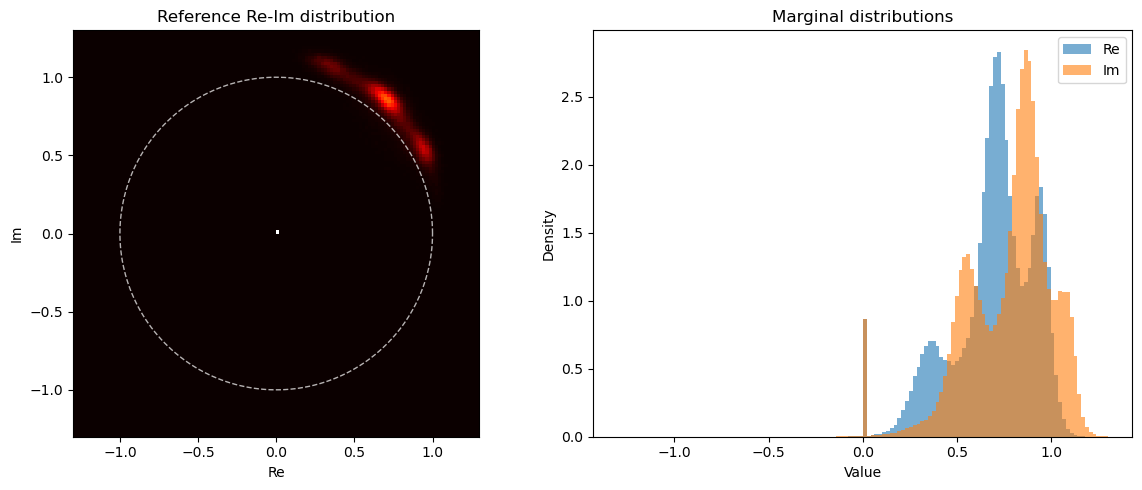

In [5]:
# Re-Im distribution of the reference object
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

hist_range = [[-1.3, 1.3], [-1.3, 1.3]]
bins = 128

# 2D joint histogram
axes[0].hist2d(ref_obj.real.ravel(), ref_obj.imag.ravel(),
               bins=bins, range=hist_range, cmap='hot')
theta = np.linspace(0, 2 * np.pi, 200)
axes[0].plot(np.cos(theta), np.sin(theta), 'w--', linewidth=1.0, alpha=0.7)
axes[0].set_xlabel('Re')
axes[0].set_ylabel('Im')
axes[0].set_title('Reference Re-Im distribution')
axes[0].set_aspect('equal')

# Marginal histograms
axes[1].hist(ref_obj.real.ravel(), bins=bins, range=(-1.3, 1.3),
             alpha=0.6, label='Re', density=True)
axes[1].hist(ref_obj.imag.ravel(), bins=bins, range=(-1.3, 1.3),
             alpha=0.6, label='Im', density=True)
axes[1].set_title('Marginal distributions')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 2. Fit Distribution Models

Three distribution models are fitted from the reference object. Different object generation methods require different models. Bottom two are most relevant, as they sample directly from the object statistics:

| Model | Function | Used by |
|---|---|---|
| **Re-Im statistics** | `compute_reim_statistics()` | `perlin_reim` |
| **2D histogram PDF** | `create_density_histogram_reim()` | `dead_leaves_reim_hist`, `dead_leaves` |
| **Gaussian Mixture Model** | `fit_gmm_from_objects()` | `dead_leaves_reim_gmm`, `white_noise_clustered` |

We fit all three here so any method can be used in the next section.

Albert's notes:
The 2d histogram PDF just samples real-imaginary values from the empirical distribution
The gaussian mixture model tries to get the overall "modes" (i.e. dominant regions) in the image, such as background, different types of contrasted features, etc.

In [9]:
ref_obj_list = [ref_obj]

# 1. Re-Im statistics
stats = compute_reim_statistics(ref_obj_list)
print('Re-Im statistics:')
for key in ['re_mean', 'im_mean', 're_std', 'im_std', 'correlation']:
    print(f'  {key}: {stats[key]:.4f}')

# 2. 2D histogram PDF
histogram, re_edges, im_edges = create_density_histogram_reim(
    ref_obj_list, origin_threshold=0.05
)
print(f'\nHistogram: shape={histogram.shape}')

# 3. Gaussian Mixture Model
gmm_params = fit_gmm_from_objects(
    ref_obj_list, n_clusters=5, origin_mask_radius=0.4
)
print(f'\nGMM clusters: {gmm_params["n_clusters"]}')
print(f'Cluster weights: {gmm_params["weights"].round(3)}')
print(f'Cluster means (Re, Im):')
for i, m in enumerate(gmm_params['means']):
    print(f'  k={i}: ({m[0]:.3f}, {m[1]:.3f})')

Re-Im statistics:
  re_mean: 0.6896
  im_mean: 0.7776
  re_std: 0.2194
  im_std: 0.2250
  correlation: -0.4616
Re-Im histogram vacuum mode: Re=0.7055, Im=0.8586

Histogram: shape=(256, 256)
n_clusters is: 5
GMM fit: K=5, centers=([0.717, 0.923, 0.358, 0.617, 0.713], [0.839, 0.557, 1.063, 0.915, 0.666]), weights=[0.35, 0.255, 0.148, 0.142, 0.106], vacuum=(0.923, 0.557)

GMM clusters: 5
Cluster weights: [0.35  0.255 0.148 0.142 0.106]
Cluster means (Re, Im):
  k=0: (0.717, 0.839)
  k=1: (0.923, 0.557)
  k=2: (0.358, 1.063)
  k=3: (0.617, 0.915)
  k=4: (0.713, 0.666)


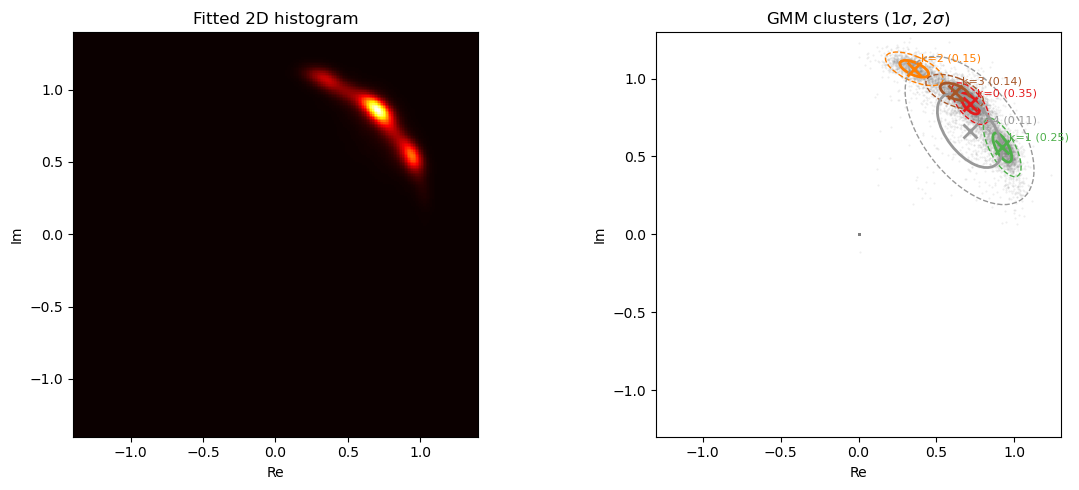

In [10]:
# Visualize fitted distribution models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: 2D histogram heatmap
re_c = 0.5 * (re_edges[:-1] + re_edges[1:])
im_c = 0.5 * (im_edges[:-1] + im_edges[1:])
axes[0].pcolormesh(re_c, im_c, histogram.T, cmap='hot')
axes[0].set_xlabel('Re')
axes[0].set_ylabel('Im')
axes[0].set_title('Fitted 2D histogram')
axes[0].set_aspect('equal')

# Right: scatter + GMM ellipses
flat = ref_obj.ravel()
subsample = flat[::max(1, len(flat) // 8000)]
axes[1].scatter(subsample.real, subsample.imag, s=0.2, alpha=0.15,
                c='gray', rasterized=True)

means = gmm_params['means']
covs = gmm_params['covariances']
weights = gmm_params['weights']
colors = plt.cm.Set1(np.linspace(0, 1, len(weights)))

for k in range(len(weights)):
    eigvals, eigvecs = np.linalg.eigh(covs[k])
    angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
    for n_std in [1, 2]:
        ell = Ellipse(
            xy=means[k],
            width=2 * n_std * np.sqrt(eigvals[1]),
            height=2 * n_std * np.sqrt(eigvals[0]),
            angle=angle,
            edgecolor=colors[k], facecolor='none',
            linewidth=2 if n_std == 1 else 1,
            linestyle='-' if n_std == 1 else '--',
        )
        axes[1].add_patch(ell)
    axes[1].plot(means[k, 0], means[k, 1], 'x', color=colors[k],
                 markersize=10, markeredgewidth=2)
    axes[1].annotate(f'k={k} ({weights[k]:.2f})', means[k], fontsize=8,
                     color=colors[k], textcoords='offset points', xytext=(5, 5))

axes[1].set_xlabel('Re')
axes[1].set_ylabel('Im')
axes[1].set_title(r'GMM clusters (1$\sigma$, 2$\sigma$)')
axes[1].set_aspect('equal')
axes[1].set_xlim(-1.3, 1.3)
axes[1].set_ylim(-1.3, 1.3)

plt.tight_layout()
plt.show()

---
## 3. Select and Configure Object Generation Method

PtychoPINN provides **13 synthetic object generation methods**. Choose one by setting `OBJ_METHOD` below.

### Methods requiring no extra data

| Method string | Description |
|---|---|
| `white_noise` | Uniform white noise mapped to amplitude/phase |
| `blurred_white_noise` | Gaussian-blurred white noise |
| `simplex_noise` | Perlin/simplex noise-based structures |
| `procedural` | Layered geometric shapes with Perlin texture |
| `polyhedra` | 3D polyhedra projection |
| `dead_leaves_reim` | Dead leaves with bivariate Gaussian Re-Im values |
| `dead_leaves_constrained` | Dead leaves with constrained phase range |
| `dead_leaves_reim_uniform` | Dead leaves with uniform Re-Im sampling |

### Methods requiring a fitted histogram

| Method string | Description |
|---|---|
| `dead_leaves` | Physics-based dead leaves with optional histogram sampling |
| `dead_leaves_reim_hist` | Dead leaves sampling from the fitted 2D histogram |

### Methods requiring fitted Re-Im statistics

| Method string | Description |
|---|---|
| `perlin_reim` | Correlated Perlin noise matched to Re-Im statistics |

### Methods requiring a fitted GMM

| Method string | Description |
|---|---|
| `dead_leaves_reim_gmm` | Dead leaves with GMM-sampled Re-Im values (recommended) |
| `white_noise_clustered` | Quantized noise mapped to GMM clusters |

In [11]:
# ============================================================
# SELECT YOUR OBJECT METHOD — change OBJ_METHOD to try others
# ============================================================
OBJ_METHOD = 'dead_leaves_reim_gmm'

# --- Automatic obj_arg construction (no need to edit below) ---
obj_arg = {}

# Mode mapping for create_dead_leaves_v3-based methods
MODE_MAP = {
    'dead_leaves_reim': 'gaussian',
    'dead_leaves_reim_hist': 'histogram',
    'dead_leaves_constrained': 'constrained_phase',
    'dead_leaves_reim_uniform': 'uniform',
}
if OBJ_METHOD in MODE_MAP:
    obj_arg['mode'] = MODE_MAP[OBJ_METHOD]

# White noise methods need a blur flag
if OBJ_METHOD in ('white_noise', 'blurred_white_noise'):
    obj_arg['blur'] = (OBJ_METHOD == 'blurred_white_noise')

# GMM-based methods need gmm_params and perturbation settings
# Most of these can be ignored or left as-is. They simply change how "varied" the samples are from our synthetic distribution.
# larger number generally means more noise
if OBJ_METHOD in ('dead_leaves_reim_gmm', 'white_noise_clustered'):
    obj_arg['gmm_params'] = gmm_params
    obj_arg['perturbation_mode'] = 'physical'
    obj_arg['phase_jitter_std'] = 0.1
    obj_arg['amplitude_scale_std'] = 0.03
    obj_arg['center_jitter_std'] = 0.05
    obj_arg['weight_dirichlet_conc'] = 5.0
    obj_arg['clip_range'] = (-1.2, 1.2)

# Build extra kwargs for simulate_synthetic_objects
gen_kwargs = {}
if OBJ_METHOD in ('dead_leaves', 'dead_leaves_reim_hist'):
    gen_kwargs['histogram'] = histogram
if OBJ_METHOD == 'perlin_reim':
    gen_kwargs['stats'] = stats

print(f'Selected method: {OBJ_METHOD}')
print(f'obj_arg keys: {list(obj_arg.keys())}')
if gen_kwargs:
    print(f'Extra kwargs: {list(gen_kwargs.keys())}')

Selected method: dead_leaves_reim_gmm
obj_arg keys: ['gmm_params', 'perturbation_mode', 'phase_jitter_std', 'amplitude_scale_std', 'center_jitter_std', 'weight_dirichlet_conc', 'clip_range']


---
## 4. Generate and Visualize Sample Objects

Generate a small batch of synthetic objects for visual inspection before committing to the full dataset. Compare amplitude/phase images and Re-Im distributions against the reference.

In [12]:
data_config = DataConfig(N=N)

n_preview = 3
sample_objects = simulate_synthetic_objects(
    IMAGE_SIZE, data_config, nimages=n_preview,
    obj_method=OBJ_METHOD, obj_arg=obj_arg,
    **gen_kwargs
)

for i, obj in enumerate(sample_objects):
    print(f'Object {i}: shape={obj.shape}, '
          f'amp=[{np.abs(obj).min():.3f}, {np.abs(obj).max():.3f}], '
          f'Re=[{obj.real.min():.3f}, {obj.real.max():.3f}]')

create_dead_leaves_reim_gmm: generated (250, 250) object, K=5, 3000 leaves
create_dead_leaves_reim_gmm: generated (250, 250) object, K=5, 3000 leaves
create_dead_leaves_reim_gmm: generated (250, 250) object, K=5, 3000 leaves
Object 0: shape=(250, 250), amp=[0.797, 1.281], Re=[0.223, 1.200]
Object 1: shape=(250, 250), amp=[0.644, 1.406], Re=[0.083, 1.200]
Object 2: shape=(250, 250), amp=[0.523, 1.357], Re=[0.037, 1.200]


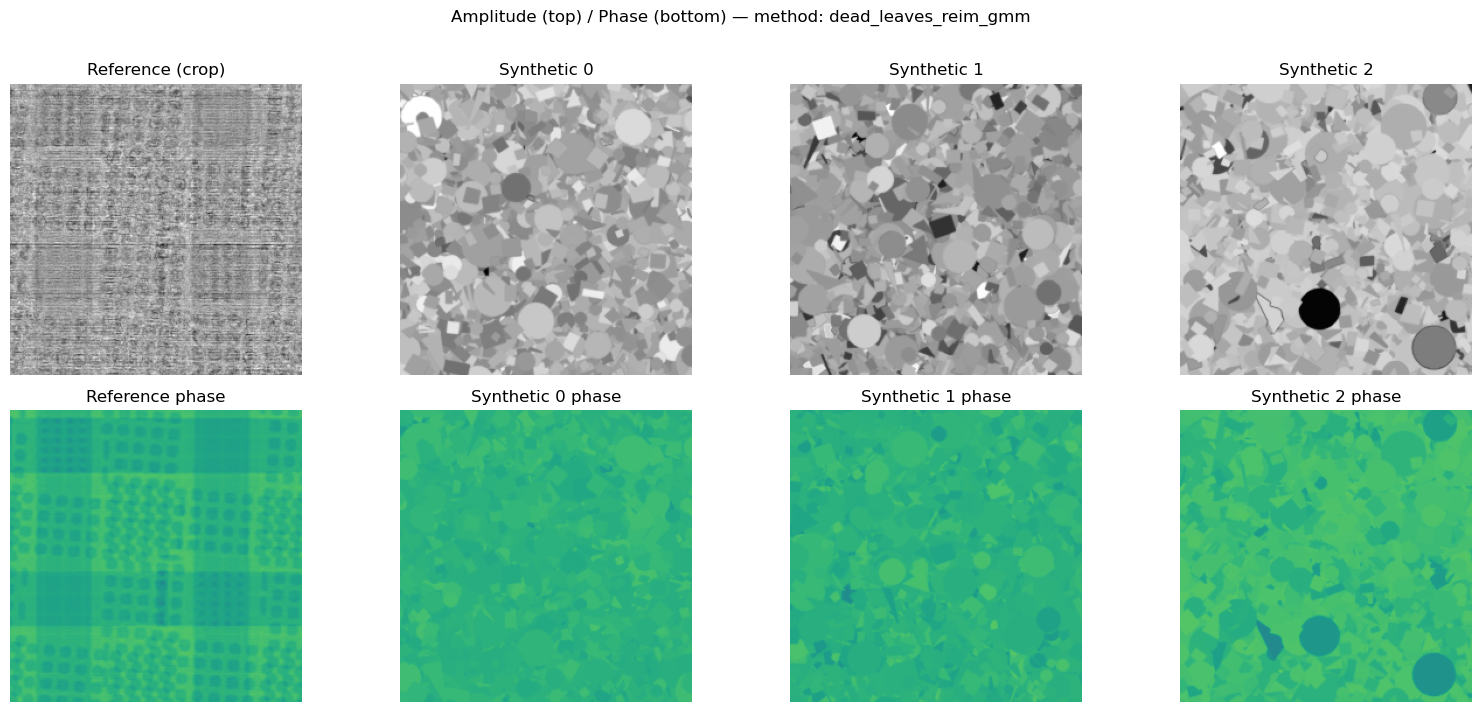

In [14]:
# Amplitude/phase comparison: reference (center-cropped) vs synthetic objects
h, w = IMAGE_SIZE
exp_crop = ref_obj[
    ref_obj.shape[0] // 2 - h // 2 : ref_obj.shape[0] // 2 + h // 2,
    ref_obj.shape[1] // 2 - w // 2 : ref_obj.shape[1] // 2 + w // 2,
]

n_cols = 1 + n_preview
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 7))

# Reference (cropped)
axes[0, 0].imshow(np.abs(exp_crop), cmap='gray')
axes[0, 0].set_title('Reference (crop)')
axes[0, 0].axis('off')
axes[1, 0].imshow(np.angle(exp_crop), cmap='viridis', vmin=-np.pi, vmax=np.pi)
axes[1, 0].set_title('Reference phase')
axes[1, 0].axis('off')

# Synthetic objects
for i in range(n_preview):
    obj = sample_objects[i]
    axes[0, i + 1].imshow(np.abs(obj), cmap='gray')
    axes[0, i + 1].set_title(f'Synthetic {i}')
    axes[0, i + 1].axis('off')
    axes[1, i + 1].imshow(np.angle(obj), cmap='viridis', vmin=-np.pi, vmax=np.pi)
    axes[1, i + 1].set_title(f'Synthetic {i} phase')
    axes[1, i + 1].axis('off')

plt.suptitle(f'Amplitude (top) / Phase (bottom) — method: {OBJ_METHOD}', y=1.01)
plt.tight_layout()
plt.show()

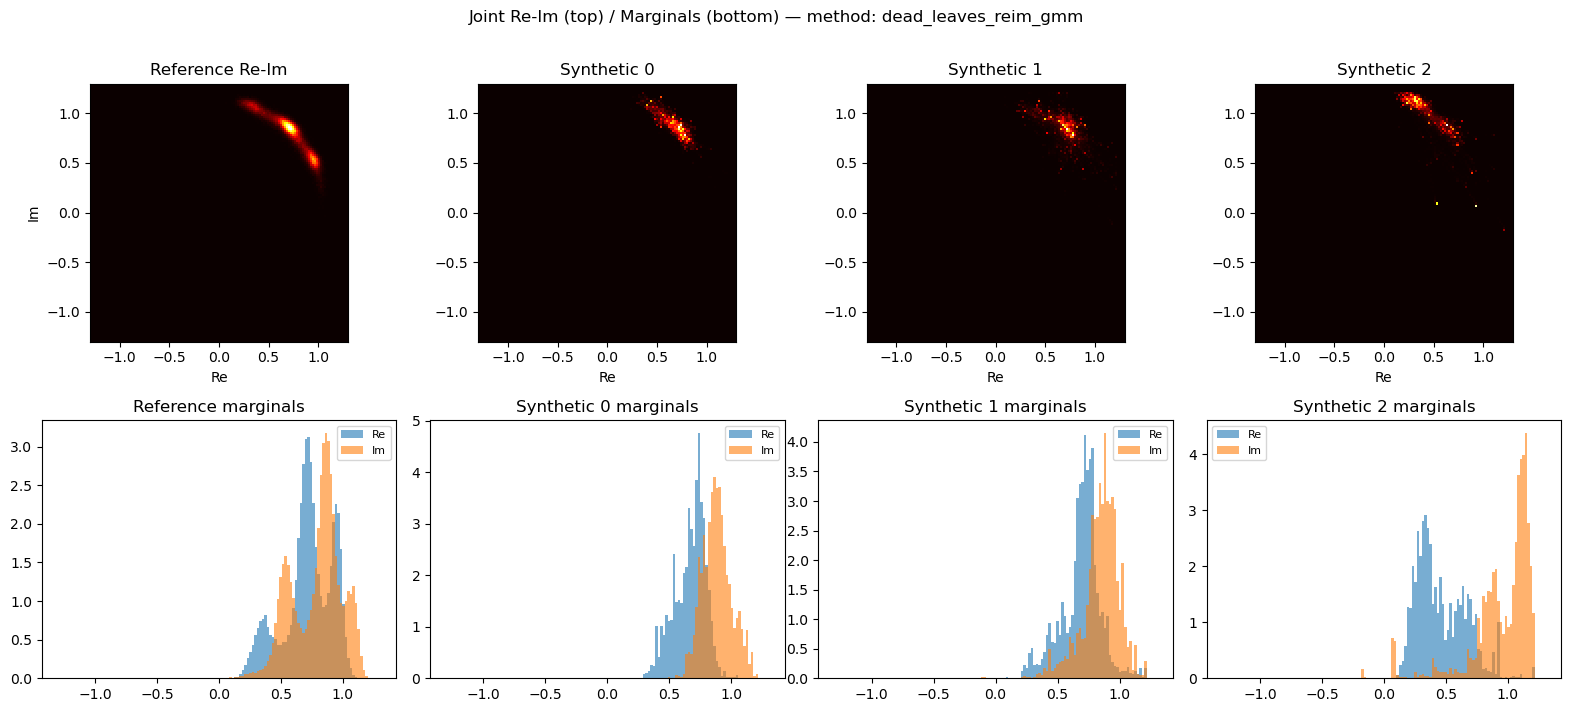

In [15]:
# Re-Im distribution comparison: reference vs synthetic objects
n_cols = 1 + n_preview
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 7))
hist_range = [[-1.3, 1.3], [-1.3, 1.3]]
bins = 128

# Reference distributions
axes[0, 0].hist2d(exp_crop.real.ravel(), exp_crop.imag.ravel(),
                  bins=bins, range=hist_range, cmap='hot')
axes[0, 0].set_title('Reference Re-Im')
axes[0, 0].set_xlabel('Re')
axes[0, 0].set_ylabel('Im')
axes[0, 0].set_aspect('equal')

axes[1, 0].hist(exp_crop.real.ravel(), bins=bins, range=(-1.3, 1.3),
                alpha=0.6, label='Re', density=True)
axes[1, 0].hist(exp_crop.imag.ravel(), bins=bins, range=(-1.3, 1.3),
                alpha=0.6, label='Im', density=True)
axes[1, 0].set_title('Reference marginals')
axes[1, 0].legend(fontsize=8)

# Synthetic distributions
for i in range(n_preview):
    obj = sample_objects[i]
    axes[0, i + 1].hist2d(obj.real.ravel(), obj.imag.ravel(),
                          bins=bins, range=hist_range, cmap='hot')
    axes[0, i + 1].set_title(f'Synthetic {i}')
    axes[0, i + 1].set_xlabel('Re')
    axes[0, i + 1].set_aspect('equal')

    axes[1, i + 1].hist(obj.real.ravel(), bins=bins, range=(-1.3, 1.3),
                        alpha=0.6, label='Re', density=True)
    axes[1, i + 1].hist(obj.imag.ravel(), bins=bins, range=(-1.3, 1.3),
                        alpha=0.6, label='Im', density=True)
    axes[1, i + 1].set_title(f'Synthetic {i} marginals')
    axes[1, i + 1].legend(fontsize=8)

plt.suptitle(f'Joint Re-Im (top) / Marginals (bottom) — method: {OBJ_METHOD}', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Generate Full Synthetic Dataset

Generate the complete training dataset. This produces `N_OBJECTS` synthetic experiments, each containing `DIFF_PER_OBJECT` simulated diffraction patterns.

Each saved NPZ file contains:
- `diff3d` — simulated diffraction intensity patterns
- `label` — ground truth object patches at each scan position
- `objectGuess` — the full synthetic object
- `probeGuess` — the probe function used for simulation
- `xcoords`, `ycoords` — scan positions

In [16]:
# Generate all synthetic objects
print(f'Generating {N_OBJECTS} objects with \'{OBJ_METHOD}\'...')
obj_list = simulate_synthetic_objects(
    IMAGE_SIZE, data_config, nimages=N_OBJECTS,
    obj_method=OBJ_METHOD, obj_arg=obj_arg,
    **gen_kwargs
)

# Prepare probe list (reuse the reference probe for all objects)
probe_list = [probe] * N_OBJECTS
probe_name_idx = list(range(N_OBJECTS))
probe_arg = {
    'probe_name_idx': probe_name_idx,
    'beamstop_diameter': 4,
}

# Prepare output directory
os.makedirs(SYNTHETIC_DATA_DIR, exist_ok=True)
if os.listdir(SYNTHETIC_DATA_DIR):
    print(f'Clearing existing files in {SYNTHETIC_DATA_DIR}...')
    remove_all_files(SYNTHETIC_DATA_DIR)

# Simulate diffraction and save NPZs
simulate_multiple_experiments(
    obj_list, probe_list, DIFF_PER_OBJECT,
    IMAGE_SIZE, data_config, probe_arg, SYNTHETIC_DATA_DIR,
)

# Verify saved files
saved_files = sorted(f for f in os.listdir(SYNTHETIC_DATA_DIR) if f.endswith('.npz'))
print(f'\nSaved {len(saved_files)} experiment files to {SYNTHETIC_DATA_DIR}')
for f in saved_files:
    with np.load(os.path.join(SYNTHETIC_DATA_DIR, f)) as d:
        print(f'  {f}: diff3d={d["diff3d"].shape}, label={d["label"].shape}')

Generating 4 objects with 'dead_leaves_reim_gmm'...
create_dead_leaves_reim_gmm: generated (250, 250) object, K=5, 2500 leaves
create_dead_leaves_reim_gmm: generated (250, 250) object, K=5, 2500 leaves
create_dead_leaves_reim_gmm: generated (250, 250) object, K=5, 2500 leaves
create_dead_leaves_reim_gmm: generated (250, 250) object, K=5, 2500 leaves
----Beginning simulation for experiment 0----
Beginning simulation...
Processing 7000 images in batches of 1000...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Getting image patches...
  Diffracting...
  Poisson scaling...
  Getting image patches...
  Diffracting...
  Poisson scaling...
Concatenating results...
----Finished saving for experiment 0 in 1.22562479972

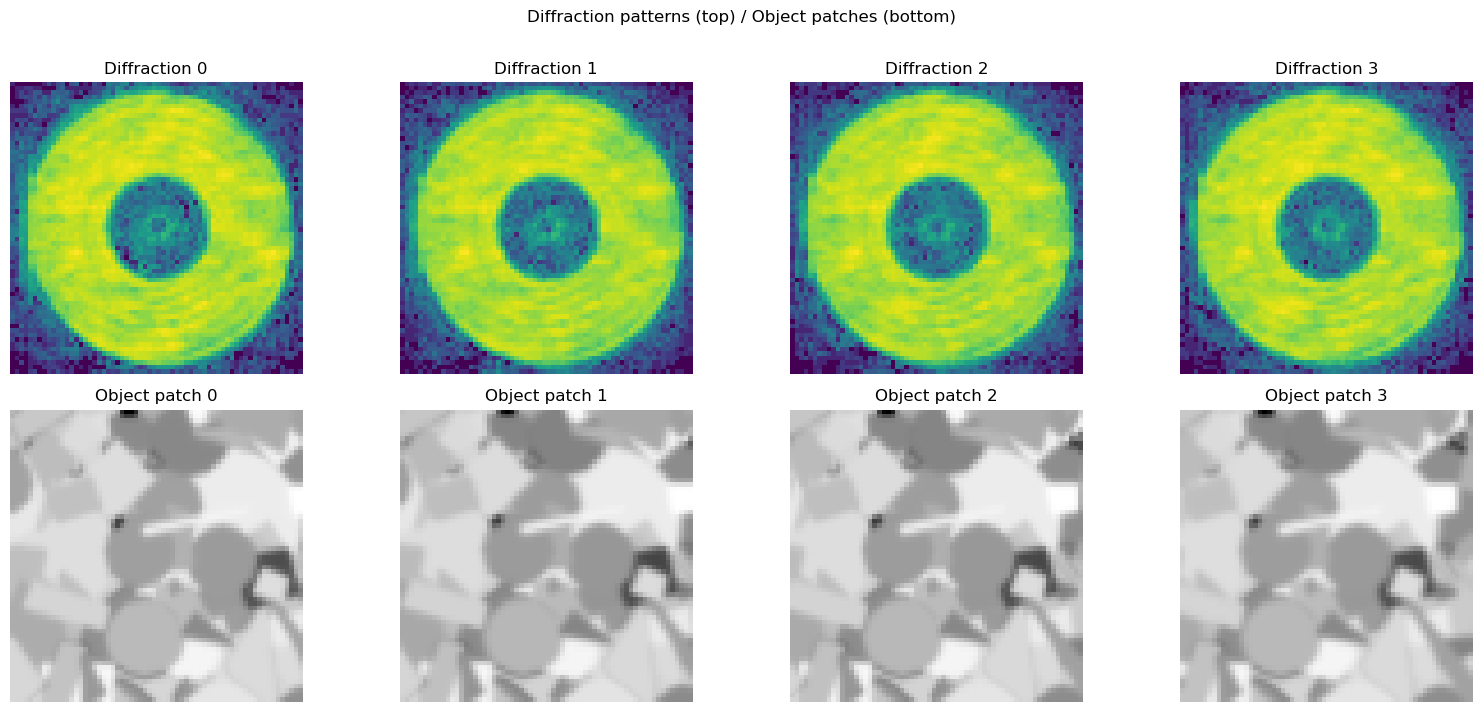

In [17]:
# Sanity check: visualize a few diffraction patterns and object patches from the first saved file
check_file = os.path.join(SYNTHETIC_DATA_DIR, saved_files[0])
check_data = np.load(check_file)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i in range(4):
    # Diffraction patterns (log scale)
    axes[0, i].imshow(np.log1p(check_data['diff3d'][i]), cmap='viridis')
    axes[0, i].set_title(f'Diffraction {i}')
    axes[0, i].axis('off')

    # Object patches (amplitude)
    axes[1, i].imshow(np.abs(check_data['label'][i]), cmap='gray')
    axes[1, i].set_title(f'Object patch {i}')
    axes[1, i].axis('off')

plt.suptitle('Diffraction patterns (top) / Object patches (bottom)', y=1.01)
plt.tight_layout()
plt.show()

check_data.close()

---
## 6. Configure and Run Training

Train using the Lightning-only path via `main_lightning()`. This returns:
- `model` — the trained `PtychoPINN_Lightning` module
- `trainer` — the Lightning Trainer object
- `run_dir` — path to the output directory with checkpoints and saved configs

### Key configuration parameters

| Parameter | Default | Notes |
|---|---|---|
| `TrainingConfig.epochs` | 15 | Increase for better convergence |
| `TrainingConfig.batch_size` | 16 | Reduce if GPU memory is limited |
| `TrainingConfig.learning_rate` | 1e-3 | Standard Adam LR |
| `TrainingConfig.n_devices` | 1 | Number of GPUs |
| `ModelConfig.mode` | Unsupervised | Supervised uses ground truth patches |
| `ModelConfig.loss_function` | Poisson | Physics-informed loss; alternative: MAE |

In [18]:
# Training configuration
data_config = DataConfig(N=N)

model_config = ModelConfig(
    mode='Unsupervised',
    loss_function='Poisson',
)

training_config = TrainingConfig(
    epochs=5,               # Increase for better convergence
    batch_size=16,
    learning_rate=1e-3,
    n_devices='auto',             # Number of GPUs
)

inference_config = InferenceConfig()
datagen_config = DatagenConfig()

existing_config = (
    data_config, model_config, training_config,
    inference_config, datagen_config
)

print('Training configuration:')
print(f'  Epochs: {training_config.epochs}')
print(f'  Batch size: {training_config.batch_size}')
print(f'  Learning rate: {training_config.learning_rate}')
print(f'  Devices: {training_config.n_devices}')
print(f'  Loss: {model_config.loss_function}')
print(f'  Mode: {model_config.mode}')
print(f'  Patch size N: {data_config.N}')

Training configuration:
  Epochs: 5
  Batch size: 16
  Learning rate: 0.001
  Devices: auto
  Loss: Poisson
  Mode: Unsupervised
  Patch size N: 64


In [ ]:
os.makedirs(TRAINING_OUTPUT_DIR, exist_ok=True)

model, trainer, run_dir = main_lightning(
    ptycho_dir=SYNTHETIC_DATA_DIR,
    existing_config=existing_config,
    output_dir=TRAINING_OUTPUT_DIR,
)

print(f'\nTraining complete!')
print(f'Run directory: {run_dir}')

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA GeForce RTX 4070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


num_datasets set to 4 (from ../../data/synthetic_pipeline_demo)
Config: 1 GPUs, batch_size=16

Creating YOUR PtychoDataModule...

Creating PtychoPINN_Lightning model... (standard)
Decoder Block 1: No attention module added.
Decoder Block 2: No attention module added.
Decoder Block 1: No attention module added.
Decoder Block 2: No attention module added.
[DataModule prepare_data] Global Rank: 0. Creating/Verifying map.
[DataModule setup] Stage: fit, Global Rank: 0. Loading map.
Creating dataset...
Calculating dataset length with coordinate bounds...
For file ../../data/synthetic_pipeline_demo/synthetic_0.npz, maximum x_range is (31.35, 218.65), yrange is (31.37, 218.57)
For file ../../data/synthetic_pipeline_demo/synthetic_1.npz, maximum x_range is (31.33, 218.67), yrange is (31.34, 218.65)
For file ../../data/synthetic_pipeline_demo/synthetic_2.npz, maximum x_range is (31.34, 218.67), yrange is (31.33, 218.62)
For file ../../data/synthetic_pipeline_demo/synthetic_3.npz, maximum x_range

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name  | Type        | Params | Mode 
----------------------------------------------
0 | model | PtychoPINN  | 3.5 M  | train
1 | Loss  | PoissonLoss | 0      | train
----------------------------------------------
3.5 M     Trainable params
0         Non-trainable params
3.5 M     Total params
13.838    Total estimated model params size (MB)
116       Modules in train mode
0         Modules in eval mode


[PtychoDataset Rank 0] Initialization successful. Dataset length: 124810.
Dataset split: Total=124810, Train=118570, Val=6240
[Rank 0] Created unique run directory: ../../data/training_pipeline_demo/run_20260616_153055
Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/local/miniconda3/envs/PtychoPINN_torch/lib/python3.10/site-packages/lightning/pytorch/core/module.py:512: You called `self.log('poisson_val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


Epoch 0:   0%|          | 0/7411 [00:00<?, ?it/s]                          
Starting Epoch 1/50
Epoch 0:   0%|          | 8/7411 [00:00<05:25, 22.72it/s, grad_norm=1.66e+4, poisson_train_loss_step=6.08e+3]

/local/miniconda3/envs/PtychoPINN_torch/lib/python3.10/site-packages/lightning/pytorch/core/module.py:512: You called `self.log('grad_norm', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/local/miniconda3/envs/PtychoPINN_torch/lib/python3.10/site-packages/lightning/pytorch/core/module.py:512: You called `self.log('poisson_train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


Epoch 0:  18%|█▊        | 1309/7411 [00:32<02:33, 39.84it/s, grad_norm=2.01e+3, poisson_train_loss_step=504.0]

In [ ]:
# List saved artifacts
print('Saved checkpoints:')
ckpt_dir = os.path.join(run_dir, 'checkpoints')
if os.path.exists(ckpt_dir):
    for f in sorted(os.listdir(ckpt_dir)):
        fpath = os.path.join(ckpt_dir, f)
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f'  {f} ({size_mb:.1f} MB)')

print('\nSaved configs:')
configs_dir = os.path.join(run_dir, 'configs')
if os.path.exists(configs_dir):
    for f in sorted(os.listdir(configs_dir)):
        print(f'  {f}')

---
## 7. Run Inference

Run reconstruction on a **separate test dataset** (not the training data). Set `INFERENCE_NPZ_PATH` in the configuration cell at the top of this notebook.

The inference function:
1. Loads the trained checkpoint from `run_dir`
2. Loads configs saved during training
3. Reconstructs the object from the test dataset
4. Generates comparison plots (amplitude/phase, Re-Im histograms)

In [ ]:
inference_data_dir = os.path.dirname(os.path.abspath(INFERENCE_NPZ_PATH))
os.makedirs(INFERENCE_OUTPUT_DIR, exist_ok=True)

print(f'Inference data directory: {inference_data_dir}')
print(f'Model from: {run_dir}')
print(f'Output to: {INFERENCE_OUTPUT_DIR}')

result = load_and_predict_lightning(
    run_path=run_dir,
    ptycho_files_dir=inference_data_dir,
    file_index=0,
    save_dir=INFERENCE_OUTPUT_DIR,
    plot_name='pipeline_demo',
    verbose=True,
    device='auto',
)

print(f'\nInference complete!')
print(f'Result shape: {result.shape}')

---
## 8. Visualize Results

The inference function saves amplitude/phase comparison plots and Re-Im histograms as SVG files. Display them inline below.

In [ ]:
# Display all saved plots
svg_files = sorted(glob.glob(os.path.join(INFERENCE_OUTPUT_DIR, '*.svg')))

if svg_files:
    for svg_file in svg_files:
        print(f'\n{os.path.basename(svg_file)}:')
        display(SVG(filename=svg_file))
else:
    print('No SVG files found. Displaying reconstruction from result tensor...')
    result_np = result.cpu().numpy()
    if result_np.ndim == 3:
        result_np = result_np[0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(np.abs(result_np), cmap='gray')
    axes[0].set_title('Reconstructed amplitude')
    axes[0].axis('off')

    axes[1].imshow(np.angle(result_np), cmap='twilight', vmin=-np.pi, vmax=np.pi)
    axes[1].set_title('Reconstructed phase')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Summary
result_np = result.cpu().numpy()
if result_np.ndim == 3:
    result_np = result_np[0]

print('=== Pipeline Summary ===')
print(f'Object method: {OBJ_METHOD}')
print(f'Training data: {N_OBJECTS} objects x {DIFF_PER_OBJECT} patterns')
print(f'Training epochs: {training_config.epochs}')
print(f'Reconstruction shape: {result_np.shape}')
print(f'Amplitude range: [{np.abs(result_np).min():.4f}, {np.abs(result_np).max():.4f}]')
print(f'Phase range: [{np.angle(result_np).min():.4f}, {np.angle(result_np).max():.4f}]')
print()
print('Next steps:')
print('  - Try a different OBJ_METHOD and re-run sections 3-5')
print('  - Increase training epochs for better convergence')
print('  - Experiment with ModelConfig options (attention, loss function)')
print('  - Use cross-dataset generation (fit GMM from one experiment, probe from another)')